# 问题三逆向验证：清水池浊度物料衡算代理模型

目标是通过相关性检验下面这个想法是否具有数据支持：

$$
C_{t+1}=C_t+\frac{\Delta t}{V_t}
\left(Q_{in,t}C_{in,t}-Q_{out,t}C_t\right),\qquad \Delta t=2\text{ h}
$$

由于数据中没有精确的 $Q_{in}$、$Q_{out}$ 和池体体积，本 notebook 使用：

| 模型量 | 数据代理 |
|---|---|
| $C_{in}$ | `FILT. NTU` |
| $C_t$ / $C_{out}$ | `NTU` |
| $V$ | `C/W WELL LEVEL`（仅作为相对体积代理） |
| $Q_{out}$ | `T/W FLOW` |
| $Q_{in}$ | 方案 A：`R/W FLOW`；方案 B：`T/W FLOW` |

检验重点不是证明严格的水力学方程，而是判断代理净负荷

$$
X_t=\frac{2}{V_t}\left(Q_{in,t}C_{in,t}-Q_{out,t}C_t\right)
$$

是否与观测变化 $\Delta C_{t+1}=C_{t+1}-C_t$ 同方向、且具有足够强的相关性。

> 注意：液位不等于体积，原水流量也不一定是清水池的即时入流。因此结果只能用于“可行性筛查”，不能直接解释为已完成物理参数标定。

## 1. 导入依赖与读取数据

优先读取 notebook 同目录的 `merged.xlsx`；若从项目根目录运行，则读取 `data/merged.xlsx`。

In [2]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr
from IPython.display import display, Markdown

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid")

candidates = [Path("merged.xlsx"), Path("../data/merged.xlsx")]
data_path = next((p for p in candidates if p.exists()), None)
if data_path is None:
    raise FileNotFoundError("未找到 merged.xlsx，请从 data 目录或项目根目录运行本 notebook。")

df = pd.read_excel(data_path, sheet_name="Merged")
df["DATETIME"] = pd.to_datetime(
    df["DATE"].astype(str) + " " + df["TIME"].astype(str)
)
df = df.sort_values("DATETIME").reset_index(drop=True)

print(f"数据文件：{data_path.resolve()}")
print(f"记录数：{len(df):,}")
print(f"时间范围：{df['DATETIME'].min()} 至 {df['DATETIME'].max()}")

数据文件：/Users/jinyu/workspace/2026亚太杯/data/merged.xlsx
记录数：5,460
时间范围：2025-01-01 07:00:00 至 2026-04-01 05:00:00


## 2. 数据质量与时间间隔

In [3]:
required = ["FILT. NTU", "NTU", "C/W WELL LEVEL", "R/W FLOW", "T/W FLOW"]
interval_hours = df["DATETIME"].diff().dt.total_seconds().div(3600)

quality = pd.DataFrame({
    "非缺失数": df[required].notna().sum(),
    "缺失数": df[required].isna().sum(),
    "缺失率": df[required].isna().mean(),
    "唯一值数": df[required].nunique(),
    "最小值": df[required].min(),
    "中位数": df[required].median(),
    "最大值": df[required].max(),
})

print("相邻记录时间间隔（小时）：")
display(interval_hours.value_counts().sort_index().rename("记录数").to_frame())
print("核心变量质量：")
display(quality.style.format({"缺失率": "{:.2%}", "最小值": "{:.3f}", "中位数": "{:.3f}", "最大值": "{:.3f}"}))

assert interval_hours.dropna().eq(2).all(), "数据并非严格 2 小时间隔，需要先重新采样。"
print("结论：全部相邻记录均为 2 小时，Δt=2 与数据采样频率一致。")

相邻记录时间间隔（小时）：


,记录数
DATETIME,
2.0,5459


核心变量质量：


,非缺失数,缺失数,缺失率,唯一值数,最小值,中位数,最大值
FILT. NTU,5460,0,0.00%,210,0.020,0.060,9.800
NTU,5124,336,6.15%,197,0.080,0.310,11.900
C/W WELL LEVEL,5460,0,0.00%,144,1.340,3.800,3.980
R/W FLOW,5460,0,0.00%,182,4.700,49.500,63.400
T/W FLOW,5460,0,0.00%,160,17.500,45.500,55.600


结论：全部相邻记录均为 2 小时，Δt=2 与数据采样频率一致。


## 3. 构造观测变化与物料衡算代理项

用当前时刻的信息预测下一个 2 小时时刻的变化：

$$
\Delta NTU_{t+1}=NTU_{t+1}-NTU_t
$$

构造两个净负荷代理：

$$
X_t^{RW}=\frac{2}{LEVEL_t}
\left(R/WFLOW_t\cdot FILT.NTU_t-T/WFLOW_t\cdot NTU_t\right)
$$

$$
X_t^{TW}=\frac{2}{LEVEL_t}
\left(T/WFLOW_t\cdot FILT.NTU_t-T/WFLOW_t\cdot NTU_t\right)
$$

绝对量纲并不严格匹配，因为 `C/W WELL LEVEL` 不是池体体积；相关性只考察共同变化方向和线性/单调关系。

In [4]:
DT_HOURS = 2
level = df["C/W WELL LEVEL"]

df["delta_NTU_next"] = df["NTU"].shift(-1) - df["NTU"]
df["in_load_RW_over_level"] = df["R/W FLOW"] * df["FILT. NTU"] / level
df["in_load_TW_over_level"] = df["T/W FLOW"] * df["FILT. NTU"] / level
df["out_load_over_level"] = df["T/W FLOW"] * df["NTU"] / level
df["net_load_RW"] = DT_HOURS * (
    df["R/W FLOW"] * df["FILT. NTU"] - df["T/W FLOW"] * df["NTU"]
) / level
df["net_load_TW"] = DT_HOURS * df["T/W FLOW"] * (
    df["FILT. NTU"] - df["NTU"]
) / level

analysis_cols = [
    "DATETIME", "delta_NTU_next", "NTU", "FILT. NTU", "C/W WELL LEVEL",
    "R/W FLOW", "T/W FLOW", "in_load_RW_over_level",
    "in_load_TW_over_level", "out_load_over_level", "net_load_RW", "net_load_TW",
]
display(df[analysis_cols].head())

,DATETIME,delta_NTU_next,NTU,FILT. NTU,C/W WELL LEVEL,R/W FLOW,T/W FLOW,in_load_RW_over_level,in_load_TW_over_level,out_load_over_level,net_load_RW,net_load_TW
0,2025-01-01 07:00:00,0.00,0.12,0.04,3.82,45.3,42.6,0.474346,0.446073,1.338220,-1.727749,-1.784293
1,2025-01-01 09:00:00,0.00,0.12,0.05,3.81,45.2,42.6,0.593176,0.559055,1.341732,-1.497113,-1.565354
2,2025-01-01 11:00:00,-0.01,0.12,0.05,3.81,44.9,42.7,0.589239,0.560367,1.344882,-1.511286,-1.569029
3,2025-01-01 13:00:00,0.00,0.11,0.05,3.58,44.9,42.3,0.627095,0.590782,1.299721,-1.345251,-1.417877
4,2025-01-01 15:00:00,0.00,0.11,0.05,3.58,44.5,42.5,0.621508,0.593575,1.305866,-1.368715,-1.424581


## 4. 分项相关性与净负荷相关性

In [5]:
def correlation_row(y, x, name):
    pair = pd.concat([y.rename("y"), x.rename("x")], axis=1).dropna()
    pearson = pearsonr(pair["y"], pair["x"])
    spearman = spearmanr(pair["y"], pair["x"])
    return {
        "变量": name,
        "样本数": len(pair),
        "Pearson r": pearson.statistic,
        "Pearson p": pearson.pvalue,
        "Spearman ρ": spearman.statistic,
        "Spearman p": spearman.pvalue,
    }

candidates_for_corr = {
    "当前 NTU": df["NTU"],
    "FILT. NTU": df["FILT. NTU"],
    "R/W FLOW × FILT. NTU / LEVEL": df["in_load_RW_over_level"],
    "T/W FLOW × FILT. NTU / LEVEL": df["in_load_TW_over_level"],
    "T/W FLOW × NTU / LEVEL": df["out_load_over_level"],
    "净负荷：R/W FLOW 作 Qin": df["net_load_RW"],
    "净负荷：T/W FLOW 作 Qin": df["net_load_TW"],
    "C/W WELL LEVEL": df["C/W WELL LEVEL"],
}

corr_table = pd.DataFrame([
    correlation_row(df["delta_NTU_next"], series, name)
    for name, series in candidates_for_corr.items()
]).sort_values("Pearson r", key=lambda s: s.abs(), ascending=False)

display(corr_table.style.format({
    "Pearson r": "{:.4f}",
    "Pearson p": "{:.3e}",
    "Spearman ρ": "{:.4f}",
    "Spearman p": "{:.3e}",
}))

print("说明：样本量较大时，即使弱相关也可能得到很小的 p 值；可行性判断应优先看 |r| 的实际大小。")

,变量,样本数,Pearson r,Pearson p,Spearman ρ,Spearman p
6,净负荷：T/W FLOW 作 Qin,5122,0.2610,1.458e-80,0.1441,3.491e-25
4,T/W FLOW × NTU / LEVEL,5122,-0.2484,7.367e-73,-0.0958,6.546e-12
0,当前 NTU,5122,-0.2435,4.773e-70,-0.0945,1.236e-11
5,净负荷：R/W FLOW 作 Qin,5122,0.2373,1.683e-66,0.1377,4.172e-23
2,R/W FLOW × FILT. NTU / LEVEL,5122,-0.0605,1.476e-05,0.0204,1.450e-01
3,T/W FLOW × FILT. NTU / LEVEL,5122,-0.0592,2.205e-05,0.0231,9.902e-02
1,FILT. NTU,5122,-0.0578,3.511e-05,0.0226,1.064e-01
7,C/W WELL LEVEL,5122,0.0036,7.983e-01,0.0652,3.030e-06


说明：样本量较大时，即使弱相关也可能得到很小的 p 值；可行性判断应优先看 |r| 的实际大小。


## 5. 控制当前 NTU 后的偏相关

净负荷公式中含有 `-Qout × NTU(t)`，因此它与浊度变化的相关性可能主要来自 `NTU(t)` 本身的均值回归。  
这里分别将 `delta_NTU_next` 和净负荷对当前 `NTU` 做线性残差化，再计算残差之间的相关性，以评估净负荷代理的额外信息。

In [6]:
def partial_corr_controlling_current_ntu(feature_name):
    part = df[["delta_NTU_next", feature_name, "NTU"]].dropna()
    control = part["NTU"].to_numpy()
    y = part["delta_NTU_next"].to_numpy()
    x = part[feature_name].to_numpy()
    y_resid = y - np.polyval(np.polyfit(control, y, 1), control)
    x_resid = x - np.polyval(np.polyfit(control, x, 1), control)
    result = pearsonr(y_resid, x_resid)
    return {
        "净负荷方案": feature_name,
        "样本数": len(part),
        "控制 NTU 后 Pearson r": result.statistic,
        "p 值": result.pvalue,
    }

partial_table = pd.DataFrame([
    partial_corr_controlling_current_ntu("net_load_RW"),
    partial_corr_controlling_current_ntu("net_load_TW"),
])
display(partial_table.style.format({"控制 NTU 后 Pearson r": "{:.4f}", "p 值": "{:.3e}"}))

,净负荷方案,样本数,控制 NTU 后 Pearson r,p 值
0,net_load_RW,5122,0.1785,6.438e-38
1,net_load_TW,5122,0.1815,3.370e-39


## 6. 入流运输滞后敏感性

`R/W FLOW` 或 `T/W FLOW` 不一定在同一记录时刻成为清水池入流。下面把入流流量和 `FILT. NTU` 同时滞后 0–12 个采样步（0–24 小时），而出流项保持在当前时刻，观察相关性是否明显增强。

各方案绝对 Pearson 相关性最大的滞后：


,变量,滞后步数,滞后小时,样本数,Pearson r,Spearman ρ
1,T/W FLOW 作 Qin,0,0,5122,0.2610,0.1441
0,R/W FLOW 作 Qin,0,0,5122,0.2373,0.1377


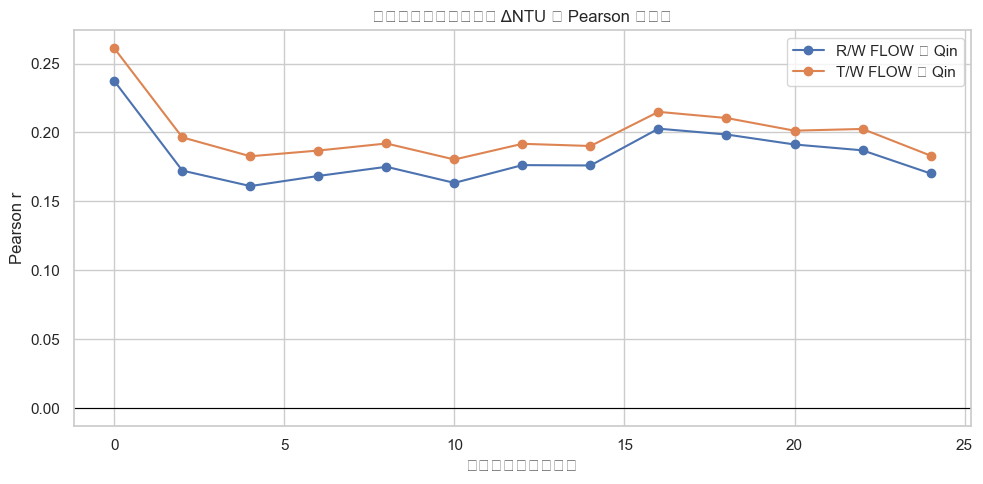

In [7]:
lag_rows = []
for lag in range(13):
    for qin_col, label in [("R/W FLOW", "R/W FLOW 作 Qin"), ("T/W FLOW", "T/W FLOW 作 Qin")]:
        delayed_in_load = (
            df[qin_col].shift(lag) * df["FILT. NTU"].shift(lag)
        )
        proxy = DT_HOURS * (
            delayed_in_load - df["T/W FLOW"] * df["NTU"]
        ) / df["C/W WELL LEVEL"]
        row = correlation_row(df["delta_NTU_next"], proxy, label)
        row["滞后步数"] = lag
        row["滞后小时"] = lag * DT_HOURS
        lag_rows.append(row)

lag_table = pd.DataFrame(lag_rows)
best_lags = (
    lag_table.assign(abs_r=lag_table["Pearson r"].abs())
    .sort_values("abs_r", ascending=False)
    .groupby("变量", as_index=False)
    .head(1)
    .drop(columns="abs_r")
)

print("各方案绝对 Pearson 相关性最大的滞后：")
display(best_lags[["变量", "滞后步数", "滞后小时", "样本数", "Pearson r", "Spearman ρ"]].style.format({
    "Pearson r": "{:.4f}", "Spearman ρ": "{:.4f}"
}))

fig, ax = plt.subplots(figsize=(10, 5))
for label, part in lag_table.groupby("变量"):
    ax.plot(part["滞后小时"], part["Pearson r"], marker="o", label=label)
ax.axhline(0, color="black", linewidth=0.8)
ax.set(title="净负荷代理与下一时刻 ΔNTU 的 Pearson 相关性",
       xlabel="入流项滞后（小时）", ylabel="Pearson r")
ax.legend()
plt.tight_layout()
plt.show()

## 7. 可视化：净负荷与实际变化

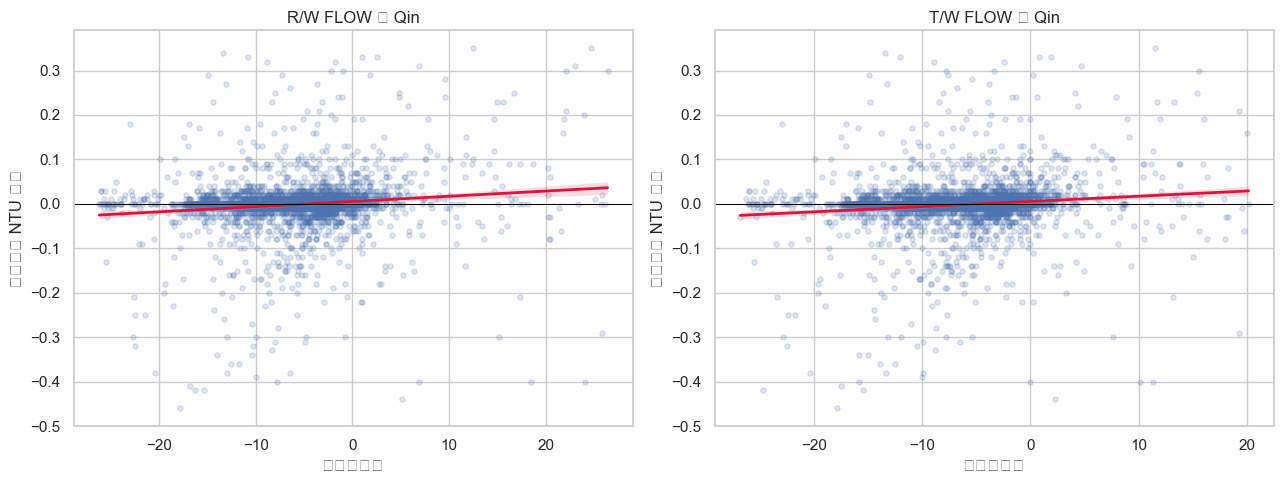

In [8]:
plot_df = df[["delta_NTU_next", "net_load_RW", "net_load_TW"]].dropna()

# 极端值会压缩主体点云，仅为可视化截取各轴 1%–99% 分位；相关系数仍使用全部有效样本。
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, feature, title in [
    (axes[0], "net_load_RW", "R/W FLOW 作 Qin"),
    (axes[1], "net_load_TW", "T/W FLOW 作 Qin"),
]:
    xlo, xhi = plot_df[feature].quantile([0.01, 0.99])
    ylo, yhi = plot_df["delta_NTU_next"].quantile([0.01, 0.99])
    shown = plot_df[
        plot_df[feature].between(xlo, xhi)
        & plot_df["delta_NTU_next"].between(ylo, yhi)
    ]
    sns.regplot(
        data=shown, x=feature, y="delta_NTU_next", ax=ax,
        scatter_kws={"alpha": 0.18, "s": 14},
        line_kws={"color": "crimson", "linewidth": 2},
    )
    ax.axhline(0, color="black", linewidth=0.7)
    ax.set_title(title)
    ax.set_xlabel("净负荷代理")
    ax.set_ylabel("下一时刻 NTU 变化")

plt.tight_layout()
plt.show()

## 8. 自动结论

In [9]:
net_rows = corr_table[corr_table["变量"].str.startswith("净负荷")].copy()
best_net = net_rows.iloc[net_rows["Pearson r"].abs().argmax()]
best_partial = partial_table.iloc[
    partial_table["控制 NTU 后 Pearson r"].abs().argmax()
]
best_lag = lag_table.iloc[lag_table["Pearson r"].abs().argmax()]

abs_r = abs(best_net["Pearson r"])
if abs_r >= 0.5:
    strength = "较强"
elif abs_r >= 0.3:
    strength = "中等"
elif abs_r >= 0.1:
    strength = "弱"
else:
    strength = "很弱"

display(Markdown(fr"""
### 可行性判断：**有一定物理合理性，但当前代理模型只得到弱相关，不宜单独作为预测方程**

- 最佳同刻净负荷方案：**{best_net['变量']}**，Pearson $r={best_net['Pearson r']:.3f}$，Spearman $\rho={best_net['Spearman ρ']:.3f}$，属于**{strength}相关**。
- 控制当前 `NTU` 后，最大偏相关为 $r={best_partial['控制 NTU 后 Pearson r']:.3f}$。说明净负荷仍包含少量额外信号，但解释力有限。
- 0–24 小时滞后扫描的最佳结果为 **{best_lag['变量']}，滞后 {int(best_lag['滞后小时'])} 小时**，Pearson $r={best_lag['Pearson r']:.3f}$；滞后没有带来数量级上的提升。
- `C/W WELL LEVEL` 只是液位而非体积，`R/W FLOW`/`T/W FLOW` 也不是经过水力停留时间校准的真实清水池入流，这是相关性偏弱的主要结构性原因。

### 建议

1. 保留该净负荷项作为后续动态模型的一个**物理启发特征**，不要把比例系数固定为 1。
2. 用历史数据估计 $\alpha,\beta,\gamma$：
   $\Delta NTU_{{t+1}}=\alpha+\beta(Q_{{in}}C_{{in}}/V)-\gamma(Q_{{out}}C_t/V)+\varepsilon_t$。
3. 若能获得清水池面积/液位-体积曲线、18ML 实际流量以及滤后水到清水池的停留时间，应重新构造真实 $V,Q_{{in}},Q_{{out}}$。
4. 后续验证应采用时间顺序训练/测试划分，并与仅使用 `NTU(t)` 的基线模型比较增量效果。
"""))


### 可行性判断：**有一定物理合理性，但当前代理模型只得到弱相关，不宜单独作为预测方程**

- 最佳同刻净负荷方案：**净负荷：T/W FLOW 作 Qin**，Pearson $r=0.261$，Spearman $\rho=0.144$，属于**弱相关**。
- 控制当前 `NTU` 后，最大偏相关为 $r=0.182$。说明净负荷仍包含少量额外信号，但解释力有限。
- 0–24 小时滞后扫描的最佳结果为 **T/W FLOW 作 Qin，滞后 0 小时**，Pearson $r=0.261$；滞后没有带来数量级上的提升。
- `C/W WELL LEVEL` 只是液位而非体积，`R/W FLOW`/`T/W FLOW` 也不是经过水力停留时间校准的真实清水池入流，这是相关性偏弱的主要结构性原因。

### 建议

1. 保留该净负荷项作为后续动态模型的一个**物理启发特征**，不要把比例系数固定为 1。
2. 用历史数据估计 $\alpha,\beta,\gamma$：
   $\Delta NTU_{t+1}=\alpha+\beta(Q_{in}C_{in}/V)-\gamma(Q_{out}C_t/V)+\varepsilon_t$。
3. 若能获得清水池面积/液位-体积曲线、18ML 实际流量以及滤后水到清水池的停留时间，应重新构造真实 $V,Q_{in},Q_{out}$。
4. 后续验证应采用时间顺序训练/测试划分，并与仅使用 `NTU(t)` 的基线模型比较增量效果。
